In [1]:
import pandas
import numpy
from matplotlib import pyplot
import seaborn

from PIL import Image

import keras

In [2]:
modelo = keras.models.load_model("cnn_32_32_64x64x1_35e.keras")

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,016 (121.16 KB)

 Trainable params: 10,338 (40.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,678 (80.78 KB)

In [5]:
! ls test/

1.jpg.webp  12.jpeg     2.jpg.webp  5.jpg.avif  8.jpg.jxl
10.jpg      13.jpg.webp 3.jpeg      6.jpg.webp  9.jpg.webp
11.jpg      14.webp     4.jpg.webp  7.jpg


In [13]:
paths = [
    "1.jpg.webp",
    "12.jpeg",
    "2.jpg.webp",
    "5.png",
    "8.png",
    "10.jpg",
    "13.jpg.webp",
    "3.jpeg",
    "6.jpg.webp",
    "9.jpg.webp",
    "11.jpg",
    "14.webp",
    "4.jpg.webp",
    "7.jpg",
]

In [21]:
import re

paths2 = []
ids2 = []

for path in paths:
    match = re.match(r"^(\d+)", path)
    if not match is None:
        id = match.group(1)

        image = Image.open(f"test/{path}")
        image = image.convert("L")
        image = numpy.ascontiguousarray(image)

        height, width = image.shape

        L = max(width, height)
        dx = L - width
        dy = L - height

        # print(width, height, L, dx, dy)

        image2 = numpy.zeros((L, L)) + 255

        image2[int(dy/2):int(dy/2)+height, int(dx/2):int(dx/2)+width] = image

        # axes[0].imshow(255 - image, cmap="Grays")
        # axes[1].imshow(255 - image2, cmap="Grays")

        Image.fromarray(image2).resize((64, 64)).convert("RGB").save(f"test_procesado/{id}.png")

        paths2.append(f"test_procesado/{id}.png")
        ids2.append(id)

paths2 = pandas.Series(paths2)

paths2


0      test_procesado/1.png
1     test_procesado/12.png
2      test_procesado/2.png
3      test_procesado/5.png
4      test_procesado/8.png
5     test_procesado/10.png
6     test_procesado/13.png
7      test_procesado/3.png
8      test_procesado/6.png
9      test_procesado/9.png
10    test_procesado/11.png
11    test_procesado/14.png
12     test_procesado/4.png
13     test_procesado/7.png
dtype: object

In [16]:
Xc = numpy.vstack(
    paths2.apply(
        lambda path: numpy.ascontiguousarray(Image.open(path).convert("L")).reshape(64, 64, 1))
        .apply(lambda x: (255 - x) / 255).values).reshape(len(paths2), 64, 64, 1)

Xc

array([[[[0.        ],
         [0.        ],
         [0.        ],
         ...,
         [0.        ],
         [0.        ],
         [0.        ]],

        [[0.        ],
         [0.        ],
         [0.        ],
         ...,
         [0.        ],
         [0.        ],
         [0.        ]],

        [[0.        ],
         [0.        ],
         [0.        ],
         ...,
         [0.        ],
         [0.        ],
         [0.        ]],

        ...,

        [[0.        ],
         [0.        ],
         [0.        ],
         ...,
         [0.        ],
         [0.        ],
         [0.        ]],

        [[0.        ],
         [0.        ],
         [0.        ],
         ...,
         [0.        ],
         [0.        ],
         [0.        ]],

        [[0.        ],
         [0.        ],
         [0.        ],
         ...,
         [0.        ],
         [0.        ],
         [0.        ]]],


       [[[0.        ],
         [0.        ],
         [0.  

In [18]:
paths2

0      test_procesado/1.png
1     test_procesado/12.png
2      test_procesado/2.png
3      test_procesado/5.png
4      test_procesado/8.png
5     test_procesado/10.png
6     test_procesado/13.png
7      test_procesado/3.png
8      test_procesado/6.png
9      test_procesado/9.png
10    test_procesado/11.png
11    test_procesado/14.png
12     test_procesado/4.png
13     test_procesado/7.png
dtype: object

In [22]:
Yp = pandas.DataFrame(modelo.predict(Xc))

Yp["ID"] = ids2
Yp["PATH"] = paths2

Yp

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


,0,1,ID,PATH
0,0.029477,0.971161,1,test_procesado/1.png
1,0.570224,0.432104,12,test_procesado/12.png
2,0.145545,0.848752,2,test_procesado/2.png
3,0.851237,0.145892,5,test_procesado/5.png
4,0.827387,0.181528,8,test_procesado/8.png
5,0.217711,0.752520,10,test_procesado/10.png
6,0.639135,0.372632,13,test_procesado/13.png
7,0.041822,0.959065,3,test_procesado/3.png
8,0.166469,0.831086,6,test_procesado/6.png
9,0.061611,0.936272,9,test_procesado/9.png


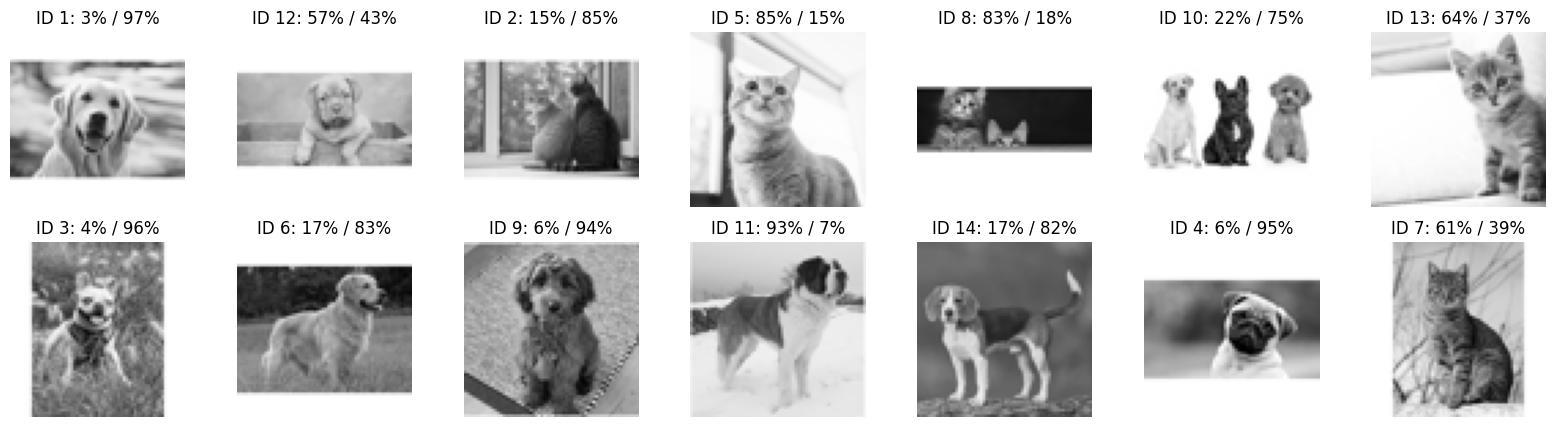

In [33]:
figure, axes = pyplot.subplots(2, 7, figsize=(20, 5))

for index, esGato, esPerro, id, path in Yp.itertuples():
    # print(id, esGato, esPerro)
    axes[int(index / 7)][index % 7].imshow(Image.open(path))
    axes[int(index / 7)][index % 7].axis("off")
    axes[int(index / 7)][index % 7].set_title(f"ID {id}: {esGato * 100:.0f}% / {esPerro * 100:.0f}%")


In [34]:
modelo.weights

[<Variable path=conv2d/kernel, shape=(5, 5, 1, 32), dtype=float32, value=[[[[ 1.14903212e-01 -1.80167437e-01  6.81517869e-02  1.13980748e-01
      4.29329760e-02 -2.02302143e-01 -1.12876296e-02  2.50212222e-01
      4.82078254e-01  2.35152125e-01 -3.43041241e-01 -1.71164617e-01
      2.20685393e-01  2.21719071e-01 -3.03732395e-01 -2.89876282e-01
     -4.75416780e-01 -1.85164884e-01  2.50566244e-01 -1.21023417e-01
      1.25796169e-01  2.87267119e-02 -1.49416596e-01 -7.29742646e-02
      7.76576549e-02 -3.27533036e-01 -4.93947983e-01  3.19311805e-02
      1.83995396e-01 -1.13681480e-01  9.66840386e-02  1.51680112e-01]]
 
   [[-5.97915761e-02  5.34396209e-02 -1.79920524e-01  1.15255073e-01
      9.30355787e-02 -1.12557031e-01 -1.06805943e-01  2.82080978e-01
      2.80455649e-01  3.27849150e-01 -7.04936534e-02  3.83364886e-01
     -3.06660771e-01  1.27874419e-01 -3.24439667e-02 -2.09158406e-01
     -1.31258771e-01 -1.02201603e-01 -8.75212625e-02  1.18410274e-01
      3.57668579e-01  1.455

## Aplicación de los filtros aprendidos para entender los fragmentos de reconocimiento

1. Cambiar del modelo secuencial al modelo manual para poder interceptar las salidas
2. Extraer cada filtro con su shape correcto (no aplanado)
3. Aplciar el filtro a una imagen para entender su transformación
4. Observar la capa después del Maxpooling
5. Observar la capa aplanada de entrenamiento (características activas finales)

        Imagen(x) -> Conv2D -> Maxpooling -> Flatten -> Dense

        Filtro 5x5 - Se aplica mediante un barrido en los 64x64 considerando si hay strides
                   - Se aplica una capa ReLU para determinar la imagen convolucionada con el filtro
                   - Esta imagen mostrará generalmente en blanco lo que se activa en la imagen y en negro el resto
                   - Además el filtro codifica la estructura del operador convolucional por lo que se puede usar para
                   - visualizar los fragmentos activados (trozos de la imagen que se hayan activado)